# Bank Marketing : Term Deposits Classification


##  Problem Statment 
The objective of this study is to analyze customer demographic and financial attributes such as age, job, marital status, education, balance, and previous campaign information to predict whether a customer will subscribe to a bank product. Using machine learning techniques like **Naive Bayes**, the model aims to identify potential customers who are more likely to respond positively to a marketing campaign.


### Steps to be followed:
1. Importing the required Libraries
2. Loading the dataset
3. Data Preprocessing
4. Checking Null values
5. Data Wrangling (Filling Null values)
6. Data Visualization
7. Machine Learning
8. Features Seletion
9. Train-Test Split
10. Model Traning
11. Model Predtion
12. Traning Score
13. Testing Score
14. GridSearch
15. F1 score
16. Cross Validation 

## Importing libraries

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report,f1_score,roc_auc_score

## importing file path

In [2]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\Test (1).csv")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


## Data Preprossesing 
### understand the data in basic way 

In [3]:
# Shows the total number of missing values in each column.
df.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [4]:
# Checks if any column contains missing values (True/False).
df.isnull().any()

age          False
job          False
marital      False
education    False
default      False
balance      False
housing      False
loan         False
contact      False
day          False
month        False
duration     False
campaign     False
pdays        False
previous     False
poutcome     False
y            False
dtype: bool

In [5]:
# Shows the first 5 rows of the dataset.
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [6]:
# Shows the last 5 rows of the dataset.
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no
4520,44,entrepreneur,single,tertiary,no,1136,yes,yes,cellular,3,apr,345,2,249,7,other,no


In [7]:
# checks the dataset for duplicate rows and returns True for duplicated records and False for unique records.
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4516    False
4517    False
4518    False
4519    False
4520    False
Length: 4521, dtype: bool

In [8]:
# Checks if any column contains missing values (True/False).
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [9]:
# Returns the number of rows and columns in the dataset.
df.shape

(4521, 17)

In [10]:
numerical_cols = [
    'age', 'balance', 'day', 'duration',
    'campaign', 'pdays', 'previous'
]

In [11]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                    'loan', 'contact', 'month', 'poutcome', 'y']


In [12]:
# Provides statistical summary of numerical columns (mean, min, max, std, etc.)
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


# Perform EDA / Data Visulization 


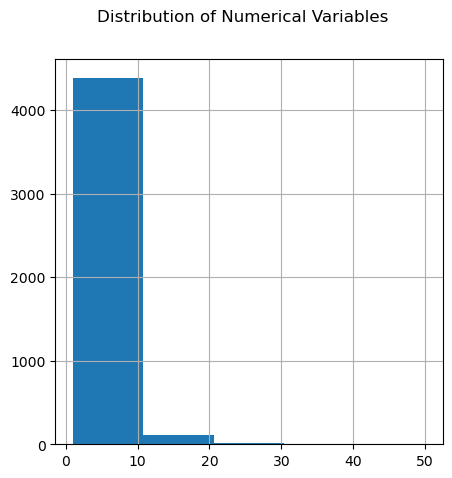

In [13]:
df['campaign'].hist(figsize=(5,5), bins=5)
plt.suptitle("Distribution of Numerical Variables")
plt.show()

## Observation:
### The histogram shows the distribution of the campaign variable, indicating how many times customers were contacted during the marketing campaign. It helps identify whether most customers were contacted few times or many times.

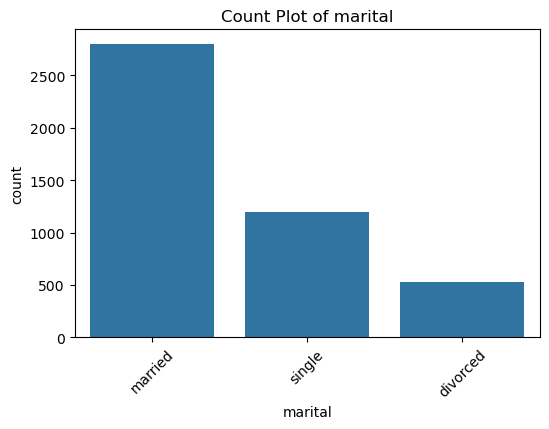

In [14]:
for col in ['marital']:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")
    plt.show()

## Observation
The count plot shows the distribution of marital status, highlighting the dominant category in the dataset

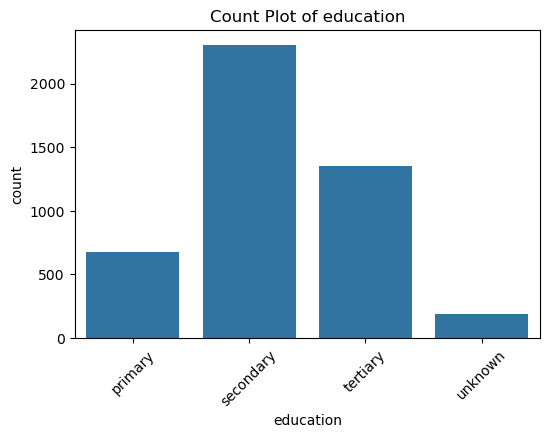

In [15]:
for col in ['education']:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")
    plt.show()

## Observation
### The count plot shows the distribution of customers based on their marital status. It helps identify which marital category (married, single, or divorced) has the highest number of customers in the dataset.


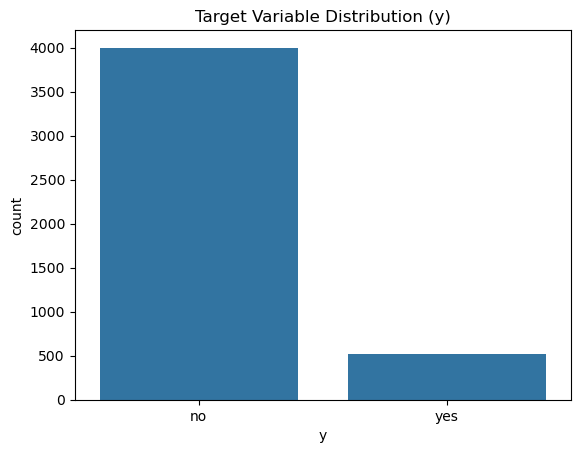

In [16]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution (y)")
plt.show()

##  Observation:
### The count plot shows the distribution of the target variable (y) in the dataset. It helps identify how many customers subscribed (yes) and did not subscribe (no) to the bank marketing offer.

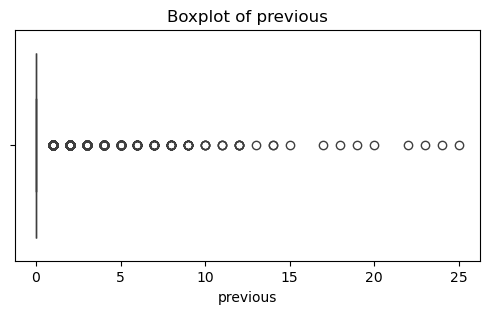

In [17]:
for col in ['previous']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


## Observation:
### The boxplot shows the distribution of the previous variable, which represents the number of contacts performed before the current campaign. It helps identify the spread of the data and detect any outliers in the number of previous contacts.

## Label Encoding

In [18]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
# This code uses Label Encoding with scikit-learn to convert all categorical (object type) columns in the dataset into numerical values, 
# so they can be used in machine learning models.

## Feature Selection (x, y)

In [19]:
X = df.drop('y', axis=1)
y = df['y']
# This code separates the dataset into features (X) and the target variable (y). 
# Here, X contains all input columns except Outcome, and y contains the Outcome column which is used for prediction.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

# This code uses Standardization with scikit-learn to scale the training and testing data so that all features have a similar range. 
# This helps distance-based models like K-Nearest Neighbors perform better.

## Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# train and test model for better observation 

## Model Training

In [22]:
model = GaussianNB()
model.fit(X_train, y_train)
# This code creates and trains a Gaussian Naive Bayes model using the training data (X_train and y_train) to learn patterns for predicting the target variable.

GaussianNB()

## Model Prediction

In [23]:
y_pred = model.predict(X_test)
# This code uses the trained K-Nearest Neighbors model to predict the target values for the test dataset (X_test) and stores the predicted results in y_pred.

## Confusion Matrix

In [24]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# This code prints the Confusion Matrix, which compares the actual values (y_test) with the predicted values (y_pred) to 
# show how many predictions are correct and incorrect for each class.

Confusion Matrix:
[[704 103]
 [ 54  44]]


## Accuracy

In [25]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# This code calculates and prints the accuracy of the model, which shows how many predictions made by the 
# K-Nearest Neighbors model are correct compared to the actual values (y_test).

Accuracy: 0.8265193370165745


## Classifiction Report 

In [26]:
print(classification_report(y_test, y_pred))

# prints the Classification Report, which shows the model’s performance using metrics like precision, recall, F1-score, and support for each class.

              precision    recall  f1-score   support

           0       0.93      0.87      0.90       807
           1       0.30      0.45      0.36        98

    accuracy                           0.83       905
   macro avg       0.61      0.66      0.63       905
weighted avg       0.86      0.83      0.84       905



## traning score

In [27]:
model.score(X_train,y_train)

0.8315818584070797

## testing Score 

In [28]:
model.score(X_test,y_test)

0.8265193370165745

## F1 score 

In [29]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.35918367346938773


## GridSearchCV

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': list(range(1,21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}


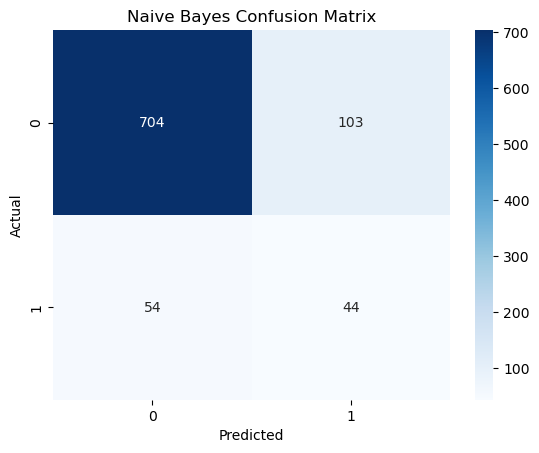

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

## Observation:
### The heatmap shows the confusion matrix of the Naive Bayes model, where the diagonal values represent correct predictions and the off-diagonal values represent incorrect predictions. Higher values on the diagonal indicate that the model is performing well in classifying the target variable.